In [138]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input,Lambda,UpSampling2D,Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization, Activation,ConvLSTM2D,TimeDistributed
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
from tensorflow.keras.callbacks         import LearningRateScheduler

import sys
import os
import numpy as np
import math
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

In [139]:
#directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

In [140]:
nbatch = 4

In [141]:
def dataset_array(g_path,p_path,v_path,vx_path,vy_path):
    """
    Loads and preprocesses a single set of data files.
    This function is designed to be used with tf.data.Dataset.map().
    """
    def load_array(geo,p,v,vx,vy):
        '''
        Inner function executed by tf.numpy_function.
        It loads numpy arrays from the provided file paths
        '''
        pre = np.load(p)   
        vel = np.load(v)
        velx = np.load(vx)
        vely = np.load(vy)
        g = np.load(geo)
        y = np.concatenate([pre, vel, velx, vely], axis=-1)
        return g,y
    
    x,y= tf.numpy_function(load_array,[g_path,p_path,v_path, vx_path,vy_path], [tf.float64,tf.float64])

    y.set_shape([y.shape[0],y.shape[1],y.shape[2]])
    x.set_shape([x.shape[0],x.shape[1],x.shape[2]])
  
    return x,y 


def create_dataset(p_path,v_path, vx_path,vy_path,g_path,batch_size = nbatch):
    p_files = sorted(glob.glob(os.path.join(p_path, "*.npy")))
    v_files = sorted(glob.glob(os.path.join(v_path, "*.npy")))
    vx_files = sorted(glob.glob(os.path.join(vx_path, "*.npy")))
    vy_files = sorted(glob.glob(os.path.join(vy_path, "*.npy")))
    g_files = sorted(glob.glob(os.path.join(g_path, "*.npy")))

    dataset = tf.data.Dataset.from_tensor_slices((p_files,v_files,vx_files,vy_files,g_files))
    dataset = dataset.map(dataset_array, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    return dataset

train_ds =create_dataset(gtrain,ptrain,vtrain,vxtrain,vytrain)
test_ds  =create_dataset(gtest,ptest,vtest,vxtest,vytest)
valid_ds =create_dataset(gval,pval,vval,vxval,vyval)


In [142]:
num_epochs    =50
patience      =10     # How long to wait after last time validation loss improved
LR            =0.001

# Model name
model_name    ="HibridoCNN"
#save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

number_of_filters = [8,16,32,64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
DECAY_RATE=0.015

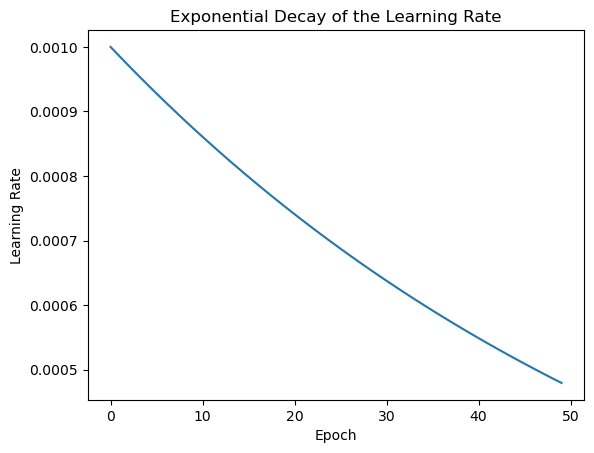

In [143]:


def exponential_decay(epoch,lr_ini=LR,decay_rate=DECAY_RATE,epochs=num_epochs):
    if epoch < epochs*0.001:
        return lr_ini
    else:
        return  lr_ini * np.exp(-decay_rate*epoch)
    
epochs = np.arange(num_epochs)
learning_rates = [exponential_decay(epoch) for epoch in epochs]


plt.plot(epochs, learning_rates, label="Learning Rate")
plt.title("Exponential Decay of the Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(False)
plt.show()  

In [144]:
lr_scheduler = LearningRateScheduler(lambda epoch: exponential_decay(epoch), verbose=1)
optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Results_weights/Best_weights.weights.h5'
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)

In [145]:
def encoder(x):
   for filters in number_of_filters: # 7 layers
    
        x=Conv2D( filters=filters,
                        kernel_size=(3, 3),
                        padding=type_padding,
                        use_bias=True)(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
   return x

def convLSTM(x):
    filters=16
    x = ConvLSTM2D(filters=filters, kernel_size=(3, 3), padding='same', return_sequences=True)(x)
    x = ConvLSTM2D(filters=filters, kernel_size=(3, 3), padding='same', return_sequences=True)(x)
    x = ConvLSTM2D(filters=filters, kernel_size=(3, 3), padding='same', return_sequences=True)(x)
    x = ConvLSTM2D(filters=filters, kernel_size=(3, 3), padding='same', return_sequences=False)(x)
    return x

def decoder(x):
    filters =[8,4,1]
    for f in filters: 
        x = layers.Conv2DTranspose(f, (3, 3), strides=(1, 1), padding='same')(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        
    return x

In [146]:
# https://g.co/gemini/share/e579fefeb1f5
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    x_enc=encoder(image_input)
    b,h,w,c = x_enc.shape
    reshaped_x = layers.Reshape((1,h,w,c))(x_enc) # time step = 1
    x=convLSTM(reshaped_x )
    x_dec=decoder(x)
    print(x_dec.shape)

    flows_out = Conv2D(4, (1, 1), activation=f_activation_last,name='flows_output',padding="same")(x)
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
    model.summary()
    model.compile(optimizer=optimizer, 
		     loss = 'mean_squared_error',
		     metrics= ['mae'])

    return model 


In [147]:
M=make_model()

(None, 64, 256, 1)


Model: "HibridoCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 256, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 256, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 256, 16)    │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 256, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 256, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64, 256, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 256, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64, 256, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 256, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64, 256, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 256, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64, 256, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 256, 512)   │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 64, 256, 512)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 64, 256,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 1, 64, 256, 16) │       304,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 1, 64, 256, 16) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 1, 64, 256, 16) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 64, 256, 16)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flows_output (Conv2D)           │ (None, 64, 256, 4)     │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,933,316 (7.38 MB)

 Trainable params: 1,933,316 (7.38 MB)

 Non-trainable params: 0 (0.00 B)

In [148]:
print("Starting trainig")

history = M.fit(train_ds,epochs=num_epochs,validation_data = valid_ds,callbacks=[early_stopping,checkpoint_cb])
callbacks = [lr_scheduler,tf.keras.callbacks.ModelCheckpoint("Unet.keras",save_best_only=True)]
M.save('Completed_Model_fourdecoders.h5')

Starting trainig
Epoch 1/50


2025-06-11 17:02:08.984832: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.111 = (f32[4,16,64,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,512,64,256]{3,2,1,0} %bitcast.9806, f32[16,512,3,3]{3,2,1,0} %bitcast.8719, f32[16]{0} %bitcast.7621, f32[4,16,64,256]{3,2,1,0} %bitcast.7636), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="HibridoCNN_1/conv_lstm2d_1/while/conv_lstm_cell_1/convolution_3" source_file="/home/ppgi/miniconda3/envs/newEnviroment/lib/python3.9/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":1,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-06-11 17:02:09.183780

350/350 ━━━━━━━━━━━━━━━━━━━━ 111s 287ms/step - loss: 0.0176 - mae: 0.0928 - val_loss: 0.0100 - val_mae: 0.0677
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - loss: 0.0100 - mae: 0.0683 - val_loss: 0.0097 - val_mae: 0.0658
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 101s 290ms/step - loss: 0.0099 - mae: 0.0669 - val_loss: 0.0096 - val_mae: 0.0657
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 102s 290ms/step - loss: 0.0098 - mae: 0.0666 - val_loss: 0.0096 - val_mae: 0.0654
Epoch 5/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - loss: 0.0098 - mae: 0.0665 - val_loss: 0.0096 - val_mae: 0.0655
Epoch 6/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 101s 289ms/step - loss: 0.0098 - mae: 0.0664 - val_loss: 0.0096 - val_mae: 0.0655
Epoch 7/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 101s 288ms/step - loss: 0.0098 - mae: 0.0664 - val_loss: 0.0096 - val_mae: 0.0653
Epoch 8/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 101s 288ms/step - loss: 0.0098 - mae: 0.0663 - val_loss: 0.0095 - val_mae: 0.0655
Epoch 9/50
350/350 ━━━━━━━━━━━━━━━━━━

In [149]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0099 - mae: 0.0676
Evaluation results:
loss: 0.0096
compile_metrics: 0.0671


In [150]:
xtrue=[]
ytrue=[]
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())
ypred = list()    
for i in range(len(ytrue)):    
    ypred.append(M.predict(xtrue[i]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [151]:
def plotting():
    n = random.randint(0, len(xtrue)-1)
    m = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true','V pred', 'V true','Vx pred', 'Vx true','Vy pred', 'Vy true']
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    
    error=[]
    for i in range(4):
            error.append(np.abs(ytrue[m][n][:,:,i]- ypred[m][n][:,:,i]))

            axes[i,0].imshow(ypred[m][n][:,:,i], cmap='gray')
            axes[i, 0].set_title(titles[2*i])
            axes[i, 0].axis('off')

            axes[i,1].imshow(ytrue[m][n][:,:,i], cmap='gray')
            axes[i, 1].set_title(titles[2*i+1])
            axes[i, 1].axis('off')

            e=axes[i,2].imshow(error[0], cmap='turbo')
            axes[i, 2].set_title('Absolute Error')
            axes[i, 2].axis('off')
            plt.colorbar(e, ax=axes[i,2], fraction=0.046)

    for ax in axes.flat:
        ax.axis('off')

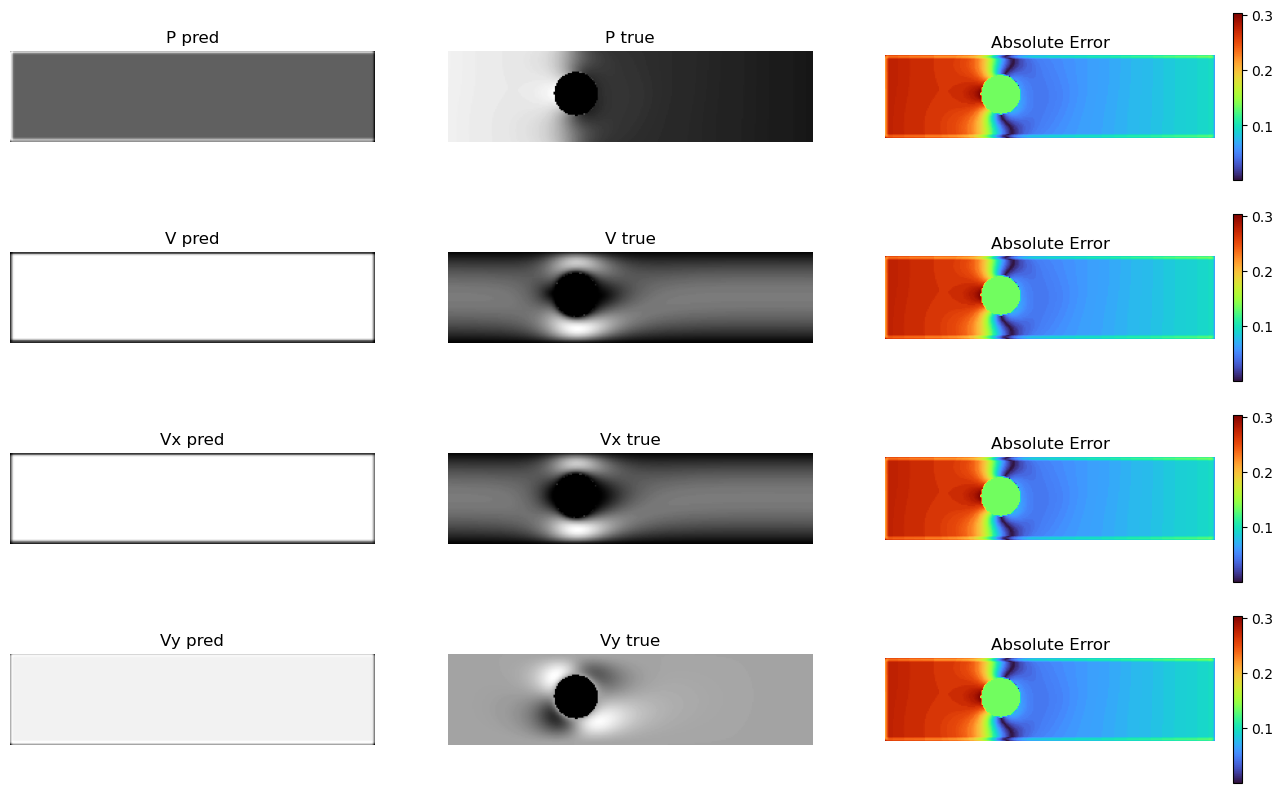

In [153]:
plotting()

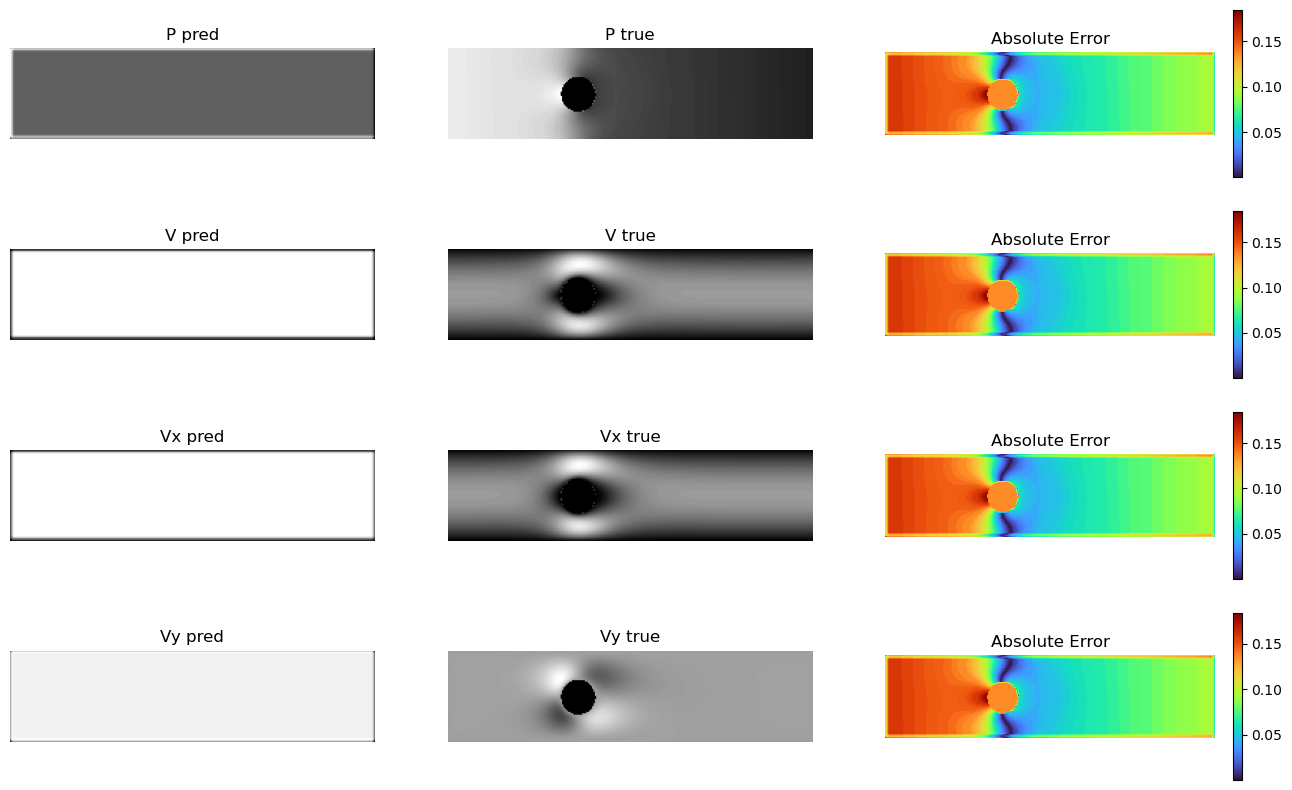

In [155]:
plotting()

IndexError: index 14 is out of bounds for axis 0 with size 4

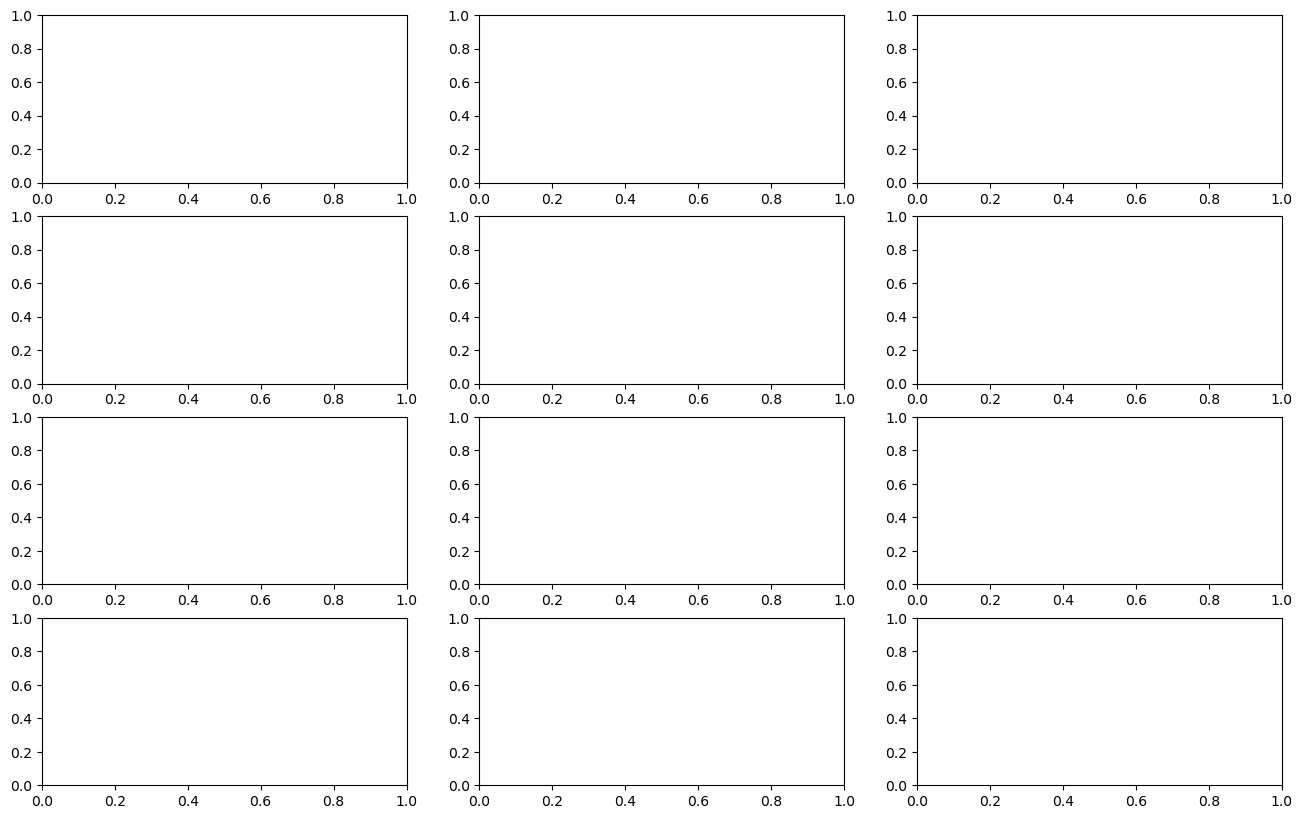

In [165]:
plotting()

In [ ]:
# Recolectar predicciones
y_preds = []
y_trues = []

for x_batch, y_batch in test_ds:
    y_pred = M.predict(x_batch)
    y_preds.append(y_pred)
    y_trues.append(y_batch)

In [ ]:
y_preds = np.concatenate(y_preds, axis=0)  # (N, H, W, 4)
y_trues = np.concatenate(y_trues, axis=0)

In [ ]:
# Calcular MSE y MAE por canal
from sklearn.metrics import mean_squared_error, mean_absolute_error
for i, var in enumerate(["p", "v", "vx", "vy"]):
    mse = mean_squared_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    mae = mean_absolute_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    print(f"{var}: MSE = {mse:.4f}, MAE = {mae:.4f}")

In [ ]:

pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(8, 5))
plt.yscale('log')       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("Pérdida vs Épocas (Escala Log)")
plt.xlabel("Epochs")
plt.ylabel("Loss (log)")
plt.tight_layout()
plt.show()


In [ ]:

pd.DataFrame(history.history)[['mae', 'val_mae']].plot(figsize=(8, 5))
plt.yscale('log')       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("Mae vs Épocas (Escala Log)")
plt.xlabel("Epochs")
plt.ylabel("Mae (log)")
plt.tight_layout()
plt.show()

In [ ]:
def encoder(x):
   for filters in number_of_filters: # 7 layers
    
        x=TimeDistributed(Conv2D( filters=filters,
                        kernel_size=(3, 3),
                        padding=type_padding,
                        use_bias=True))(x)
        x = TimeDistributed(layers.LeakyReLU(negative_slope=0.2))(x)
   return x

def decoder(x):
    filters =[8,4,1]
    for f in filters: # 7 layers
        x = layers.Conv2DTranspose(64, (3, 3), strides=(1, 2), padding='same')(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        
    x = layers.Conv2DTranspose(1, (3, 3), strides=(1, 4), padding='same')(x) 
    x = layers.LeakyReLU(negative_slope=0.2)(x) 
    return x


def convLSTM(x):
    x = ConvLSTM2D(filters=16, kernel_size=(3, 3), padding='same', return_sequences=True)(x)
 
    x = ConvLSTM2D(filters=16, kernel_size=(3, 3), padding='same', return_sequences=True)(x)
    
    x = ConvLSTM2D(filters=16, kernel_size=(3, 3), padding='same', return_sequences=True)(x)
    
    x = ConvLSTM2D(filters=16, kernel_size=(3, 3), padding='same', return_sequences=False)(x)

    return x

def make_model():
    image_input = Input((img_height, img_width, channel))
    x=layers.Permute((2, 1, 3))(image_input) # sequence w = 256 as temporal axis
    x=layers.Reshape((img_width,img_height,channel,1))(x)
    #x= layers.Reshape((1, 64, 256, 1))(image_input)
    x_encoder = encoder(x)
    x_convLSTM = convLSTM(x_encoder)
    x_decoder = decoder(x_convLSTM)

 
    flows_out = Conv2D(4, (1, 1), activation=f_activation_last,name='flows_output',padding="same")(x_decoder)
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
    model.summary()
    model.compile(optimizer=optimizer, 
		     loss = 'mean_squared_error',
		     metrics= ['mae'])

    return model    